**Importing Dataset**

In [5]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

#SMART ZIP EXTRACTION
zip_filename = "/content/drive/MyDrive/AI and Machine Learning/FruitinAmazon.zip"

print("Looking for the dataset zip file...")

if os.path.exists(zip_filename):
    print(f"Found {zip_filename}. Extracting...")
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(".")          # Extract everything
    print("Extraction completed!")
else:
    print(f"{zip_filename} not found in the current folder.")
    print("Please upload FruitinAmazon.zip and run this cell again.")
    raise FileNotFoundError("Zip file not found.")

# AUTO-DETECT train/ and test/ folders
def find_dataset_folders():
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs and 'test' in dirs:
            train_path = os.path.join(root, 'train')
            test_path = os.path.join(root, 'test')
            print(f"Found dataset at: {root}")
            return train_path, test_path
    # Fallback: look for any folder named 'train'
    for root, dirs, files in os.walk('.'):
        if 'train' in dirs:
            return os.path.join(root, 'train'), None
    return None, None

train_dir, test_dir = find_dataset_folders()

if train_dir and os.path.exists(train_dir):
    print(f"Train folder set to: {train_dir}")
else:
    print("Could not find 'train' folder even after extraction.")
    print("Please check the zip structure and tell me what folders you see after extraction.")

if test_dir and os.path.exists(test_dir):
    print(f"Test folder set to : {test_dir}")
else:
    print("'test' folder not found (some datasets have only train). Using validation split instead.")

%matplotlib inline
plt.style.use('seaborn-v0_8')
print("Setup complete! You can now run the next cells.")

Looking for the dataset zip file...
Found /content/drive/MyDrive/AI and Machine Learning/FruitinAmazon.zip. Extracting...
Extraction completed!
Found dataset at: ./FruitinAmazon
Train folder set to: ./FruitinAmazon/train
Test folder set to : ./FruitinAmazon/test
Setup complete! You can now run the next cells.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Task 1: Data Understanding and Visualization:**

Found 6 classes: ['pupunha', 'cupuacu', 'acai', 'graviola', 'tucuma', 'guarana']


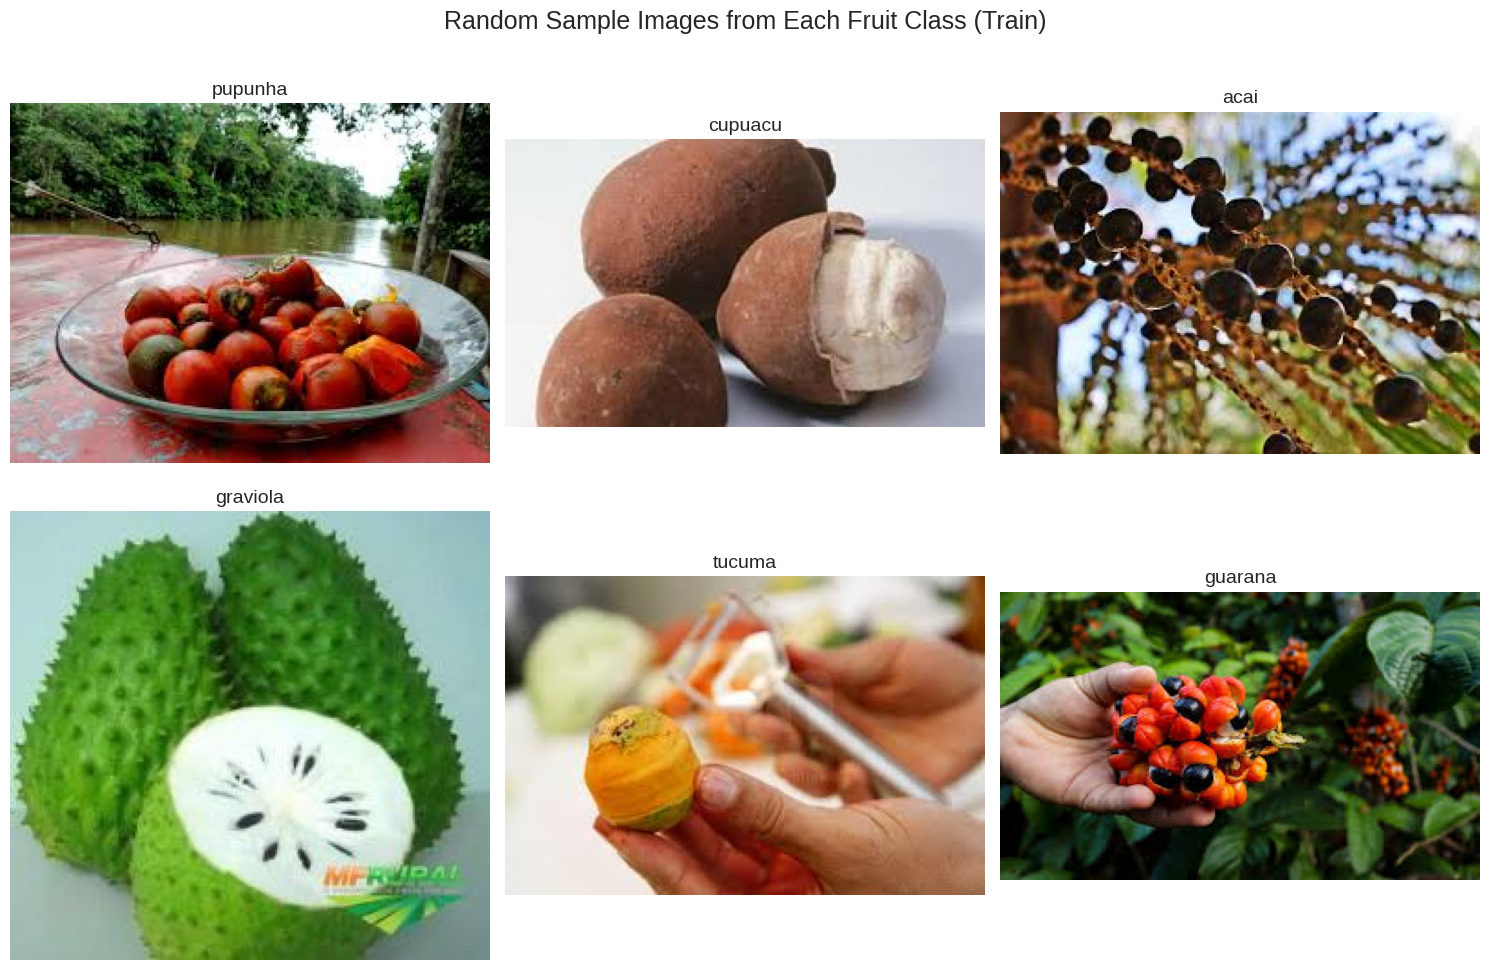

In [6]:
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print(f"Found {len(classes)} classes: {classes}")

images_to_show = []
labels_to_show = []

for cls in classes:
    class_dir = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if img_files:
        img_file = random.choice(img_files)
        img_path = os.path.join(class_dir, img_file)
        images_to_show.append(img_path)
        labels_to_show.append(cls)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Random Sample Images from Each Fruit Class (Train)', fontsize=18)

for i, ax in enumerate(axes.flat):
    if i < len(images_to_show):
        img = Image.open(images_to_show[i])
        ax.imshow(img)
        ax.set_title(labels_to_show[i], fontsize=14)
        ax.axis('off')

plt.tight_layout()
plt.show()

**Check for Corrupted Image**

In [7]:
def check_corrupted(train_dir):
    corrupted = []
    for cls in os.listdir(train_dir):
        class_dir = os.path.join(train_dir, cls)
        if os.path.isdir(class_dir):
            for filename in os.listdir(class_dir):
                img_path = os.path.join(class_dir, filename)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                except (UnidentifiedImageError, IOError, SyntaxError):
                    corrupted.append(img_path)
                    os.remove(img_path)
                    print(f"🗑 Removed: {img_path}")
    print("No corrupted images found." if not corrupted else f"Removed {len(corrupted)} corrupted images.")
check_corrupted(train_dir)

No corrupted images found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [8]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# 1. Create datasets FIRST (before mapping)
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

# 2. Get class_names BEFORE applying map (this is the fix)
class_names = raw_train_ds.class_names
num_classes = len(class_names)

# 3. Now apply normalization
train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = raw_val_ds.map(lambda x, y: (rescale(x), y))
test_ds  = raw_test_ds.map(lambda x, y: (rescale(x), y))

print(f"Classes: {class_names}")
print(f"Training samples : {len(train_ds) * batch_size}")
print(f"Validation samples: {len(val_ds) * batch_size}")
print(f"Test samples     : {len(test_ds) * batch_size}")
print("Datasets loaded and normalized successfully!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Training samples : 80
Validation samples: 32
Test samples     : 32
Datasets loaded and normalized successfully!


**Task 3 - Implement a CNN with**
**Follow the following Structure and Hyper - parameters:**

In [9]:
#TASK 3: CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                           input_shape=(img_height, img_width, 3)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),

    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Compile the Model**

In [10]:
#TASK 4: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint('best_fruit_model.h5', monitor='val_loss',
                             save_best_only=True, mode='min', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)

history = model.fit(train_ds, epochs=250, validation_data=val_ds,
                    callbacks=[checkpoint, early_stop])

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1382 - loss: 2.3843
Epoch 1: val_loss improved from None to 2.06601, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.1806 - loss: 2.4089 - val_accuracy: 0.0000e+00 - val_loss: 2.0660
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.1413 - loss: 1.7802
Epoch 2: val_loss improved from 2.06601 to 1.89244, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.1389 - loss: 1.7732 - val_accuracy: 0.1111 - val_loss: 1.8924
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.2413 - loss: 1.6996
Epoch 3: val_loss improved from 1.89244 to 1.78690, saving model to best_fruit_model.h5



Epoch 3: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 555ms/step - accuracy: 0.2639 - loss: 1.6734 - val_accuracy: 0.0556 - val_loss: 1.7869
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.2705 - loss: 1.5346
Epoch 4: val_loss improved from 1.78690 to 1.73933, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.3472 - loss: 1.5112 - val_accuracy: 0.1111 - val_loss: 1.7393
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.5771 - loss: 1.2776
Epoch 5: val_loss improved from 1.73933 to 1.45877, saving model to best_fruit_model.h5


...


Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.6389 - loss: 1.0333 - val_accuracy: 0.6111 - val_loss: 1.1257
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7937 - loss: 0.7209
Epoch 7: val_loss improved from 1.12565 to 1.01390, saving model to best_fruit_model.h5



Epoch 7: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.7500 - loss: 0.7604 - val_accuracy: 0.6111 - val_loss: 1.0139
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8882 - loss: 0.4436
Epoch 8: val_loss improved from 1.01390 to 0.60477, saving model to best_fruit_model.h5



Epoch 8: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.8889 - loss: 0.4730 - val_accuracy: 0.8889 - val_loss: 0.6048
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9330 - loss: 0.2847
Epoch 9: val_loss improved from 0.60477 to 0.46568, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - accuracy: 0.9306 - loss: 0.2929 - val_accuracy: 0.9444 - val_loss: 0.4657
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9104 - loss: 0.2506
Epoch 10: val_loss did not improve from 0.46568
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 463ms/step - accuracy: 0.9167 - loss: 0.2379 - val_accuracy: 0.6667 - val_loss: 0.6494
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9837 - loss: 0.1287
Epoch 11: val_loss did not improve from 0.46568
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.9861 - loss: 0.1152 - val_accuracy: 0.8333 - val_loss: 0.4762
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 1.0000 - loss: 0.0812
Epoch 12: val_loss improved from 0.46568 to 0.24389, saving model to best_fruit_model.h5



Epoch 12: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 1.0000 - loss: 0.0699 - val_accuracy: 0.8889 - val_loss: 0.2439
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9837 - loss: 0.0474
Epoch 13: val_loss did not improve from 0.24389
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 376ms/step - accuracy: 0.9861 - loss: 0.0376 - val_accuracy: 0.8889 - val_loss: 0.3911
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 1.0000 - loss: 0.0233
Epoch 14: val_loss did not improve from 0.24389
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 444ms/step - accuracy: 1.0000 - loss: 0.0275 - val_accuracy: 0.8333 - val_loss: 0.4489
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 1.0000 - loss: 0.0237
Epoch 15: val_loss did not improve from 0.24389
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 1.0000 - loss: 0.0224 - val_accuracy: 0.8333 - val_loss: 0.4096
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 1.0000 - loss: 0.0

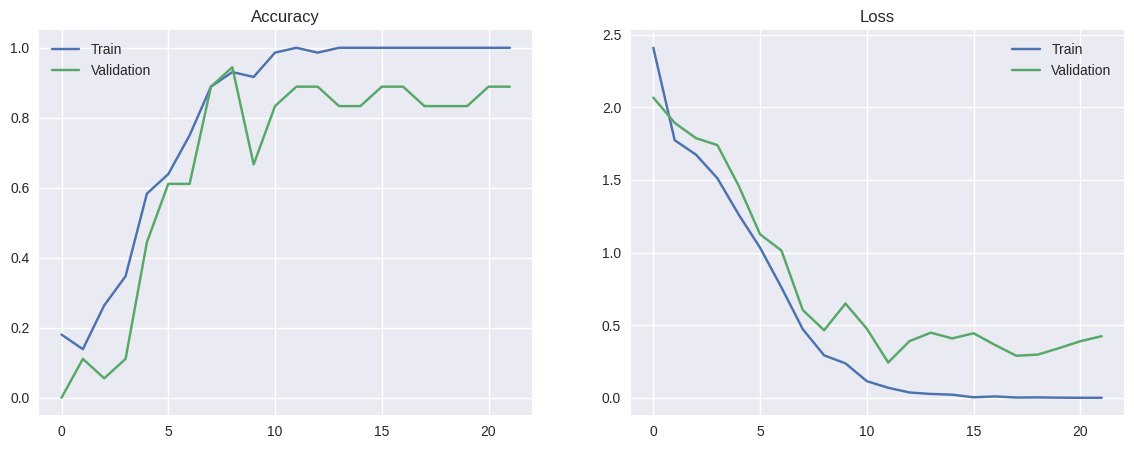

In [11]:
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss'); plt.legend()
plt.show()

**Task 5: Evaluate the Model**

In [12]:
#TASK 5: Evaluate on Test Set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7667 - loss: 0.6333
Test Accuracy: 0.7667 | Test Loss: 0.6333


**Task 6: Save and Load the Model**

In [13]:
model.save('fruit_classifier_final.h5')
print("Model saved as fruit_classifier_final.h5")
loaded_model = tf.keras.models.load_model('fruit_classifier_final.h5')
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"Loaded model Test Accuracy: {loaded_acc:.4f}")

Model saved as fruit_classifier_final.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7667 - loss: 0.6333
Loaded model Test Accuracy: 0.7667


**Task 7: Predictions and Classification Report**

In [14]:
# TASK 7: Classification Report on Test
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = []
for _, labels in test_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

print("="*70)
print("CLASSIFICATION REPORT (TEST SET)")
print("="*70)
print(classification_report(true_labels, predicted_labels,
                           target_names=class_names, digits=2))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      0.80      0.89         5
     guarana       1.00      0.60      0.75         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.75      0.60      0.67         5

    accuracy                           0.77        30
   macro avg       0.85      0.77      0.77        30
weighted avg       0.85      0.77      0.77        30

